# 2 bus load flow

# Lastflytanalyse for 2-buss-system

## Formål

Denne oppgaven kan løses ved hjelp av:

1. Gauss-Seidel-metoden
2. Newton-Raphson-metoden
3. Pandapower
4. DIgSILENT PowerFactory

Målet er å sammenligne resultatene fra håndregning med resultatene fra programvare.

---

# Systembeskrivelse

En slack-buss forsyner en last gjennom en transmisjonslinje.

```text
      Bus 1 (Slack)
      V₁ = 1∠0°
           |
           |
      Z = j0.1 pu
           |
           |
      Bus 2 (PQ)
      P = 0.5 pu
      Q = 0.2 pu
```

---

# Basisverdier

Velg følgende baseverdier:$ S_{base}=100\text{ MVA}$, $V_{base}=11\text{ kV}$

Buss 1 (Slack); $V_1=1.0\angle0^\circ$

Buss 2 (PQ) Last: $P_2=-0.5\ pu$, $Q_2=-0.2\ pu$

Negativt fortegn betyr effektforbruk.

Linjeimpedans:$Z_{12}=j0.1\ pu$, Admittans: $Y_{12}=\frac{1}{j0.1}=-j10$



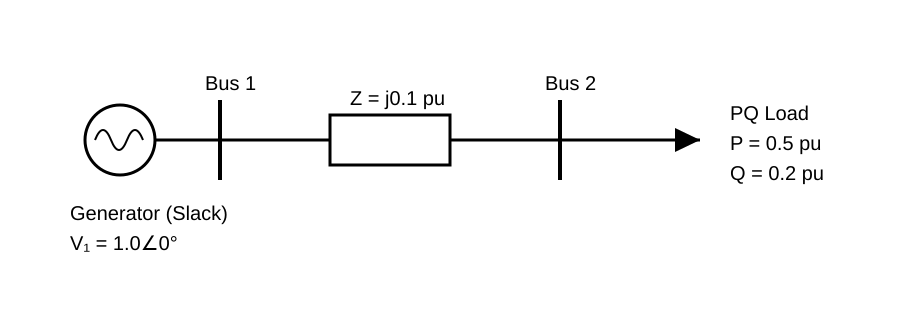

In [7]:
# TEST CELL
from myst_nb import glue
from IPython.display import SVG

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="900" height="320" viewBox="0 0 900 320">

  <style>
    .bus { stroke:black; stroke-width:4; }
    .line { stroke:black; stroke-width:3; fill:none; }
    .label { font-family:Arial, sans-serif; font-size:20px; }
  </style>

  <!-- Generator symbol -->
  <circle cx="120" cy="140" r="35"
          fill="white" stroke="black" stroke-width="3"/>

  <!-- Sine wave -->
  <path d="M95 140
           Q103 120 111 140
           Q119 160 127 140
           Q135 120 143 140"
        fill="none"
        stroke="black"
        stroke-width="2"/>

  <!-- Connection to bus 1 -->
  <line class="line" x1="155" y1="140" x2="220" y2="140"/>

  <!-- Bus 1 -->
  <line class="bus" x1="220" y1="100" x2="220" y2="180"/>

  <!-- Line to impedance -->
  <line class="line" x1="220" y1="140" x2="330" y2="140"/>

  <!-- Impedance rectangle -->
  <rect x="330" y="115"
        width="120"
        height="50"
        fill="white"
        stroke="black"
        stroke-width="3"/>

  <!-- Line after impedance -->
  <line class="line" x1="450" y1="140" x2="560" y2="140"/>

  <!-- Bus 2 -->
  <line class="bus" x1="560" y1="100" x2="560" y2="180"/>

  <!-- Load arrow -->
  <line class="line" x1="560" y1="140" x2="700" y2="140"/>

  <polygon points="700,140 675,128 675,152"
           fill="black"/>

  <!-- Labels -->
  <text class="label" x="70" y="220">
    Generator (Slack)
  </text>

  <text class="label" x="70" y="250">
    V₁ = 1.0∠0°
  </text>

  <text class="label" x="205" y="90">
    Bus 1
  </text>

  <text class="label" x="350" y="105">
    Z = j0.1 pu
  </text>

  <text class="label" x="545" y="90">
    Bus 2
  </text>

  <text class="label" x="730" y="120">
    PQ Load
  </text>

  <text class="label" x="730" y="150">
    P = 0.5 pu
  </text>

  <text class="label" x="730" y="180">
    Q = 0.2 pu
  </text>

</svg>
"""

glue("last_flyt", SVG(svg), display=True)

---

# Y-bus-matrise

For et 2-buss-system fås

$$
Y_{bus}
=
\begin{bmatrix}
Y_{11} & Y_{12}\\
Y_{21} & Y_{22}
\end{bmatrix}
$$

hvor

$$
Y_{11}=Y_{22}=-j10
$$

$$
Y_{12}=Y_{21}=j10
$$

Dermed

$$
Y_{bus}
=
\begin{bmatrix}
-j10 & j10\\
j10 & -j10
\end{bmatrix}
$$

---

# Oppgave A: Gauss-Seidel

## Flat start

Velg startverdien $V_2^{(0)}=1+j0$

---

## Oppdateringsformel

For PQ-buss 2: $V_2^{(r+1)}=\frac{1}{Y_{22}}\left[\frac{P_2-jQ_2}{\left(V_2^{(k)}\right)^*}-Y_{21}V_1\right]$

---

## Oppgaver
a)Beregn første iterasjon; $V_2^{(1)}$

b)Beregn andre iterasjon; $V_2^{(2)}$

c) Fortsett iterasjonene til $|V_2^{(k+1)}-V_2^{(k)}|<10^{-6}$

d) Bestem sluttverdiene |V_2| og $\delta_2$

---

# Oppgave B: Newton-Raphson

## Tilstandsvariabler

Tilstandsvektoren er; $x =\begin{bmatrix}\delta_2\\V_2\end{bmatrix}$

---

## Effektligninger

Aktiv effekt: $P_2=V_2V_1\left(G_{21}\cos\delta_2+B_{21}\sin\delta_2\right)+V_2^2G_{22}$

Reaktiv effekt: $Q_2=V_2V_1\left(G_{21}\sin\delta_2-B_{21}\cos\delta_2\right)-V_2^2B_{22}$


## Oppgaver

a) Utfør flat start $V_2^{(0)}=1$; $\delta_2^{(0)}=0$

b) Beregn; $P_{2,\text{calc}}$ og $Q_{2,\text{calc}}$

c) Beregn mismatch-vektoren; $\Delta f = \begin{bmatrix} \Delta P_2\\ \Delta Q_2 \end{bmatrix}$

der $\Delta P_2 = P_{spec}-P_{calc}$ og $\Delta Q_2 = Q_{spec}-Q_{calc}$

d) Sett opp Jacobian-matrisen; $J = \begin{bmatrix}\frac{\partial P_2}{\partial \delta_2} & \frac{\partial P_2}{\partial V_2}\\\frac{\partial Q_2}{\partial \delta_2}&\frac{\partial Q_2}{\partial V_2}\end{bmatrix}$

e) Løs; $J\Delta x = \Delta f$

f) Oppdater; $x^{(1)} = x^{(0)} + \Delta x$

---

g) Gjenta til konvergens.

---

# Oppgave C: Pandapower

Bruk følgende script.

```python
import pandapower as pp

net = pp.create_empty_network()

# Busser
b1 = pp.create_bus(net, vn_kv=11, name="Bus 1")
b2 = pp.create_bus(net, vn_kv=11, name="Bus 2")

# Slack
pp.create_ext_grid(
    net,
    bus=b1,
    vm_pu=1.0
)

# Impedans
pp.create_impedance(
    net,
    from_bus=b1,
    to_bus=b2,
    rft_pu=0.0,
    xft_pu=0.1,
    sn_mva=100
)

# Last
pp.create_load(
    net,
    bus=b2,
    p_mw=50,
    q_mvar=20
)

# Lastflyt
pp.runpp(net, algorithm="nr")

print(net.res_bus)
```

---

## Oppgaver

a) Kjør scriptet.

b) Noter; |V_2| og $\delta_2$

c)Sammenlign resultatene med Newton-Raphson.


# Oppgave D: DIgSILENT PowerFactory

Opprett følgende komponenter:

Bus 1 
- ElmTerm
- 11 kV

External Grid
- ElmXnet
- 1.0 pu

Linje
- ElmLne

Impedans: $Z=j0.1\ pu$

Bus 2
- ElmTerm
- 11 kV

Last
- ElmLod $P=50\ MW$ og $Q=20\ MVAr$

Lastflyt

Velg:

```text
Calculate → Load Flow
```

---

## Oppgaver
a)Kjør lastflyten.
 
b) Noter; |V_2| og $\delta_2$

c) Sammenlign med:
- Gauss-Seidel
- Newton-Raphson
- Pandapower

---

# Forventet læringsutbytte

Etter øvingen skal du kunne:

- etablere Y-bus-matrisen
- utføre Gauss-Seidel-lastflyt
- utføre Newton-Raphson-lastflyt
- forstå mismatch-vektoren
- forstå Jacobian-matrisen
- modellere samme nett i Pandapower
- modellere samme nett i PowerFactory
- verifisere håndregninger mot programvare

In [32]:
import pandapower as pp

net = pp.create_empty_network()

b1 = pp.create_bus(net, vn_kv=11)
b2 = pp.create_bus(net, vn_kv=11)

pp.create_ext_grid(net, b1, vm_pu=1.0)

pp.create_impedance(
    net,
    from_bus=b1,
    to_bus=b2,
    rft_pu=0.0,
    xft_pu=0.1,
    sn_mva=100
)

pp.create_load(
    net,
    bus=b2,
    p_mw=50,
    q_mvar=20
)

pp.runpp(
net,
algorithm="gs",
max_iteration=3,
init="flat",
tolerance_mva=1e-1
)

print(net.res_bus)

pp.runpp(
net,
algorithm="nr",
max_iteration=2,
init="flat",
tolerance_mva=1e-1
)

print(net.res_bus)

      vm_pu  va_degree  p_mw     q_mvar
0  1.000000   0.000000 -50.0 -23.020833
1  0.978258  -2.929737  50.0  20.000000
      vm_pu  va_degree  p_mw     q_mvar
0  1.000000   0.000000 -50.0 -23.030016
1  0.978252  -2.929636  50.0  20.000000
